In [1]:
import numpy as np
import pandas as pd
from collections import Counter
import warnings, os, gc, re
import matplotlib.pyplot as plt
import swifter
import psutil
import math

# from plotnine import ggplot, aes, geom_line
from plotnine import *
# import pygal as pg
%matplotlib inline

import missingno as msno
import pprint

warnings.filterwarnings('ignore')
pd.options.display.float_format = '{:.4f}'.format

In [2]:
path, dirs, files = next(os.walk("chunks_3/test/"))
directory = "chunks_3/test/"
file_count = len(files)

In [3]:
# count number of rows
from itertools import (takewhile,repeat)
def rawincount(filename):
    f = open(filename, 'rb')
    bufgen = takewhile(lambda x: x, (f.raw.read(1024*1024) for _ in repeat(None)))
    return sum( buf.count(b'\n') for buf in bufgen )

# compute for memory usage
def usage():
    process = psutil.Process(os.getpid())
    return process.memory_info()[0] / float(2 ** 20)

In [4]:
def garbage_collector():
    for i in range(4):
        print('Collecting %d ...' % i)
        n = gc.collect()
        print('Unreachable objects:', n)
        print('Remaining Garbage:',) 
        pprint.pprint(gc.garbage)
        print

def num_rows_actual_amt(dframe, tab_name, amt_field, writer1):
    total_year = len(dframe)
    total_na = len(dframe[dframe[amt_field].isna()])
    total_more_10M = len(dframe[dframe[amt_field] >= 10000000])
    total_more_1M = len(dframe[dframe[amt_field] >= 1000000])
    total_less_1M = len(dframe[(dframe[amt_field] < 1000000)])
    total_less_500k = len(dframe[(dframe[amt_field] <= 500000)])
    total_less_300k = len(dframe[(dframe[amt_field] <= 300000)])
    total_less_200k = len(dframe[(dframe[amt_field] <= 200000)])
    total_less_100k = len(dframe[(dframe[amt_field] <= 100000)])
    total_less_50k = len(dframe[(dframe[amt_field] <= 50000)])
    total_less_25k = len(dframe[(dframe[amt_field] <= 25000)])
    total_less_10k = len(dframe[(dframe[amt_field] <= 10000)])
    total_less_5k = len(dframe[(dframe[amt_field] <= 5000)])    
    total_less_1k = len(dframe[(dframe[amt_field] <= 1000)])    
    total_500_or_less = len(dframe[(dframe[amt_field] <= 500)])
    total_less_0to1 = len(dframe[(dframe[amt_field] < 1) & (dframe[amt_field] >= 0)])
    total_neg = len(dframe[(dframe[amt_field] < 0)])
    df_stats = pd.DataFrame([['No. of Rows with No ' + amt_field + ' keyed in', total_na, 100*total_na/total_year],
                            ['No. of Rows with ' + amt_field + ' > 10M', total_more_10M, 100*total_more_10M/total_year],
                            ['No. of Rows with ' + amt_field + ' >= 1M', total_more_1M, 100*total_more_1M/total_year],                             
                            ['No. of Rows with ' + amt_field + ' < 1M', total_less_1M, 100*total_less_1M/total_year],
                            ['No. of Rows with ' + amt_field + ' <= 500k', total_less_500k, 100*total_less_500k/total_year],
                            ['No. of Rows with ' + amt_field + ' <= 300k', total_less_300k, 100*total_less_300k/total_year],
                            ['No. of Rows with ' + amt_field + ' <= 200k', total_less_200k, 100*total_less_200k/total_year],
                            ['No. of Rows with ' + amt_field + ' <= 100k', total_less_100k, 100*total_less_100k/total_year],
                            ['No. of Rows with ' + amt_field + ' <= 50k', total_less_50k, 100*total_less_50k/total_year],
                            ['No. of Rows with ' + amt_field + ' <= 25k', total_less_25k, 100*total_less_25k/total_year],
                            ['No. of Rows with ' + amt_field + ' <= 10k', total_less_10k, 100*total_less_10k/total_year],
                            ['No. of Rows with ' + amt_field + ' <= 5k', total_less_5k, 100*total_less_5k/total_year],                             
                            ['No. of Rows with ' + amt_field + ' <= 1k', total_less_1k, 100*total_less_1k/total_year],                                                          
                            ['No. of Rows with ' + amt_field + ' <= 500', total_500_or_less, 100*total_500_or_less/total_year], 
                            ['No. of Rows with ' + amt_field + ' bet 0.0-1.0', total_less_0to1, 100*total_less_0to1/total_year],
                            ['No. of Rows with Negative ' + amt_field, total_neg, 100*total_neg/total_year],
                            ['Total No. of Rows', total_year, 100*total_year/total_year]],
                           columns=['Rows', 'Freq.', 'Percent'])
    df_stats.to_excel(writer1, sheet_name=tab_name, index=False)
    del[df_stats]

In [34]:
# plot histograms of counts per given amount field
def plot_histo(dframe, amt_field, upper_lim, lower_lim, bin_width, graph_title):
    df2 = dframe[(dframe[amt_field] <= upper_lim) & \
              (~dframe[amt_field].isna()) & \
              (dframe[amt_field] >= lower_lim)][amt_field].to_frame()

    med_value = df2[amt_field].median()
    q_25 = df2[amt_field].quantile(0.25)
    q_75 = df2[amt_field].quantile(0.75)
    max_val = len(df2[amt_field])

    p = ggplot(aes(x=amt_field), data=df2)
    p + geom_histogram(binwidth=bin_width, 
    #                    fill='blue',     # fill color
    #                    breaks=list(np.arange(0, 100000, 2000)),
                       colour='black', # outline color
                       size=0.5,        # thickness of outline
                       alpha=0.5        # transparency
                       ) \
        + geom_vline(
            mapping = aes(xintercept = med_value),
            linetype = "dashed",
            color = "red",
            size = 0.5
            ) \
        + geom_vline(
            mapping = aes(xintercept = q_25),
            linetype = "dashed",
            color = "blue",
            size = 0.5
            ) \
        + geom_vline(
            mapping = aes(xintercept = q_75),
            linetype = "dashed",
            color = "green",
            size = 0.5
            ) \
        + ggtitle(graph_title) \
        + annotate('label',x=med_value, y=math.inf, size=5, color='red', va='top', label=med_value) \
        + annotate('label',x=med_value, y=0, size=6, color='red', va='top', label='Median') \
        + annotate('label',x=q_25, y=math.inf, size=5, color='blue', va='top', label=q_25) \
        + annotate('label',x=q_25, y=0, size=6, color='blue', va='top', label='P25') \
        + annotate('label',x=q_75, y=math.inf, size=5, color='green', va='top', label=q_75) \
        + annotate('label',x=q_75, y=0, size=6, color='green', va='top', label='P75') \
        + theme_minimal()
    return p

In [42]:
files_med_proc = ['58120', '59409', '59513', '59514', '66987', '77401', '90935', 
                  '96408', '99432', '99460', 'MCP01', 'NSD01',   
                  'A91.1', 'A09.9', 'A97.1', 'I10.1', 'I10.9', 'J18.92', 
                  'J45.90', 'K29.1', 'N18.0', 'N39.0', 'P36.9']

length_list = len(files_med_proc)
year_start = 2013
year_end = 2020

In [59]:
# actual amounts aggregation counts
for i in range(length_list):
    df_input = pd.read_csv(os.path.join(directory + files_med_proc[i] + '.csv'), low_memory=False)
    df_input = df_input[['YEAR', 'ACTUAL_AMT']]
    
    writer = pd.ExcelWriter(os.path.join(directory, files_med_proc[i] + '_totals.xlsx'), engine='xlsxwriter')
    num_rows_actual_amt(df_input, 'All Years Actual Amounts', 'ACTUAL_AMT', writer)
    
    for j in range(year_start, year_end+1):
        df_input_year = df_input[(df_input['YEAR'] == j)]
        if len(df_input_year) > 0: 
            num_rows_actual_amt(df_input_year, str(j), 'ACTUAL_AMT', writer)
            del[df_input_year]
        
    writer.save()
    
    del[df_input]
#     garbage_collector() 
    gc.collect()
    gc.collect()
    gc.collect()

In [43]:
# paid amounts aggregation counts
for i in range(length_list):
    df_input = pd.read_csv(os.path.join(directory + files_med_proc[i] + '.csv'), low_memory=False)    
    df_input = df_input[['YEAR', 'PAID AMOUNT']]
    
    writer = pd.ExcelWriter(os.path.join(directory, files_med_proc[i] + '_totals.xlsx'), engine='xlsxwriter')
    num_rows_actual_amt(df_input, 'All Years Actual Amounts', 'PAID AMOUNT', writer)
    
    for j in range(year_start, year_end+1):
        df_input_year = df_input[(df_input['YEAR'] == j)]
        if len(df_input_year) > 0: 
            num_rows_actual_amt(df_input_year, str(j), 'PAID AMOUNT', writer)
            del[df_input_year]
        
    writer.save()
    
    del[df_input]
#     garbage_collector() 
    gc.collect()
    gc.collect()
    gc.collect()

In [ ]:
# get 0 ACTUAL_AMT counts divided by total counts per hospital
# reference: https://pandas.pydata.org/docs/user_guide/merging.html
# tst code: pd.concat([df1, df4.reindex(df1.index)], axis=1)

## Med Plots

### A09.9

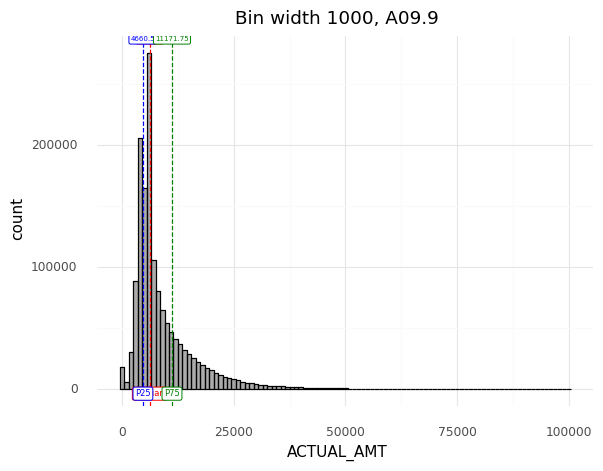

<ggplot: (129231666288)>

In [44]:
med_code = 'A09.9'
amt_field = 'ACTUAL_AMT'
upper_lim = 100000
lower_lim = 1
bin_width = 1000

dframe = pd.read_csv(os.path.join(directory + med_code + '.csv'), low_memory=False)

df2 = dframe[(dframe[amt_field] <= upper_lim) & \
          (~dframe[amt_field].isna()) & \
          (dframe[amt_field] >= lower_lim)][amt_field].to_frame()

med_value = df2[amt_field].median()
q_25 = df2[amt_field].quantile(0.25)
q_75 = df2[amt_field].quantile(0.75)
max_val = len(df2[amt_field])
graph_title = 'Bin width 1000, ' + med_code

p = ggplot(aes(x=amt_field), data=df2)
p + geom_histogram(binwidth=bin_width, 
#                    fill='blue',     # fill color
#                    breaks=list(np.arange(0, 100000, 2000)),
                   colour='black', # outline color
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(graph_title) \
    + geom_vline(
        mapping = aes(xintercept = med_value),
        linetype = "dashed",
        color = "red",
        size = 0.5
        ) \
    + annotate('label',x=med_value, y=math.inf, size=5, color='red', va='top', label=med_value) \
    + annotate('label',x=med_value, y=0, size=6, color='red', va='top', label='Median') \
    + geom_vline(
        mapping = aes(xintercept = q_25),
        linetype = "dashed",
        color = "blue",
        size = 0.5
        ) \
    + annotate('label',x=q_25, y=math.inf, size=5, color='blue', va='top', label=q_25) \
    + annotate('label',x=q_25, y=0, size=6, color='blue', va='top', label='P25') \
    + geom_vline(
        mapping = aes(xintercept = q_75),
        linetype = "dashed",
        color = "green",
        size = 0.5
        ) \
    + annotate('label',x=q_75, y=math.inf, size=5, color='green', va='top', label=q_75) \
    + annotate('label',x=q_75, y=0, size=6, color='green', va='top', label='P75') \
    + theme_minimal()

# for i in range(length_list):
#     df_input = pd.read_csv(os.path.join(directory + files_med_proc[i] + '.csv'), low_memory=False)
#     plot_histo(df_input, 'ACTUAL_AMT', 100000.0, 1.0, 1000, 'Bin width 1000' + files_med_proc[i])    

### A91.1

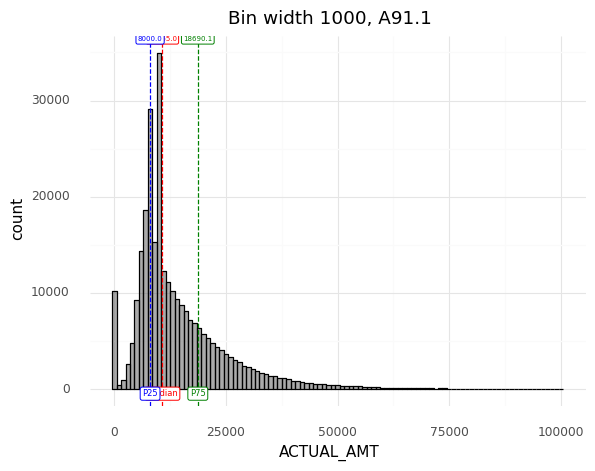

<ggplot: (129201241531)>

In [45]:
med_code = 'A91.1'
amt_field = 'ACTUAL_AMT'
upper_lim = 100000
lower_lim = 1
bin_width = 1000

dframe = pd.read_csv(os.path.join(directory + med_code + '.csv'), low_memory=False)

df2 = dframe[(dframe[amt_field] <= upper_lim) & \
          (~dframe[amt_field].isna()) & \
          (dframe[amt_field] >= lower_lim)][amt_field].to_frame()

med_value = df2[amt_field].median()
q_25 = df2[amt_field].quantile(0.25)
q_75 = df2[amt_field].quantile(0.75)
max_val = len(df2[amt_field])
graph_title = 'Bin width 1000, ' + med_code

p = ggplot(aes(x=amt_field), data=df2)
p + geom_histogram(binwidth=bin_width, 
#                    fill='blue',     # fill color
#                    breaks=list(np.arange(0, 100000, 2000)),
                   colour='black', # outline color
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(graph_title) \
    + geom_vline(
        mapping = aes(xintercept = med_value),
        linetype = "dashed",
        color = "red",
        size = 0.5
        ) \
    + annotate('label',x=med_value, y=math.inf, size=5, color='red', va='top', label=med_value) \
    + annotate('label',x=med_value, y=0, size=6, color='red', va='top', label='Median') \
    + geom_vline(
        mapping = aes(xintercept = q_25),
        linetype = "dashed",
        color = "blue",
        size = 0.5
        ) \
    + annotate('label',x=q_25, y=math.inf, size=5, color='blue', va='top', label=q_25) \
    + annotate('label',x=q_25, y=0, size=6, color='blue', va='top', label='P25') \
    + geom_vline(
        mapping = aes(xintercept = q_75),
        linetype = "dashed",
        color = "green",
        size = 0.5
        ) \
    + annotate('label',x=q_75, y=math.inf, size=5, color='green', va='top', label=q_75) \
    + annotate('label',x=q_75, y=0, size=6, color='green', va='top', label='P75') \
    + theme_minimal()

# for i in range(length_list):
#     df_input = pd.read_csv(os.path.join(directory + files_med_proc[i] + '.csv'), low_memory=False)
#     plot_histo(df_input, 'ACTUAL_AMT', 100000.0, 1.0, 1000, 'Bin width 1000' + files_med_proc[i])    

### A97.1

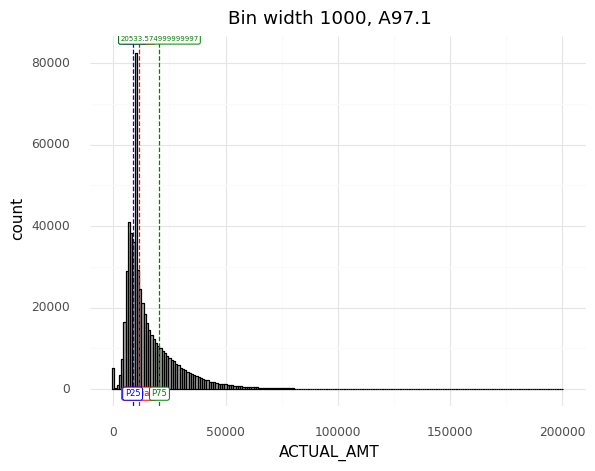

<ggplot: (129200990407)>

In [46]:
med_code = 'A97.1'
amt_field = 'ACTUAL_AMT'
upper_lim = 200000
lower_lim = 1
bin_width = 1000

dframe = pd.read_csv(os.path.join(directory + med_code + '.csv'), low_memory=False)

df2 = dframe[(dframe[amt_field] <= upper_lim) & \
          (~dframe[amt_field].isna()) & \
          (dframe[amt_field] >= lower_lim)][amt_field].to_frame()

med_value = df2[amt_field].median()
q_25 = df2[amt_field].quantile(0.25)
q_75 = df2[amt_field].quantile(0.75)
max_val = len(df2[amt_field])
graph_title = 'Bin width 1000, ' + med_code

p = ggplot(aes(x=amt_field), data=df2)
p + geom_histogram(binwidth=bin_width, 
#                    fill='blue',     # fill color
#                    breaks=list(np.arange(0, 100000, 2000)),
                   colour='black', # outline color
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(graph_title) \
    + geom_vline(
        mapping = aes(xintercept = med_value),
        linetype = "dashed",
        color = "red",
        size = 0.5
        ) \
    + annotate('label',x=med_value, y=math.inf, size=5, color='red', va='top', label=med_value) \
    + annotate('label',x=med_value, y=0, size=6, color='red', va='top', label='Median') \
    + geom_vline(
        mapping = aes(xintercept = q_25),
        linetype = "dashed",
        color = "blue",
        size = 0.5
        ) \
    + annotate('label',x=q_25, y=math.inf, size=5, color='blue', va='top', label=q_25) \
    + annotate('label',x=q_25, y=0, size=6, color='blue', va='top', label='P25') \
    + geom_vline(
        mapping = aes(xintercept = q_75),
        linetype = "dashed",
        color = "green",
        size = 0.5
        ) \
    + annotate('label',x=q_75, y=math.inf, size=5, color='green', va='top', label=q_75) \
    + annotate('label',x=q_75, y=0, size=6, color='green', va='top', label='P75') \
    + theme_minimal()

# for i in range(length_list):
#     df_input = pd.read_csv(os.path.join(directory + files_med_proc[i] + '.csv'), low_memory=False)
#     plot_histo(df_input, 'ACTUAL_AMT', 100000.0, 1.0, 1000, 'Bin width 1000' + files_med_proc[i])    

### I10.1

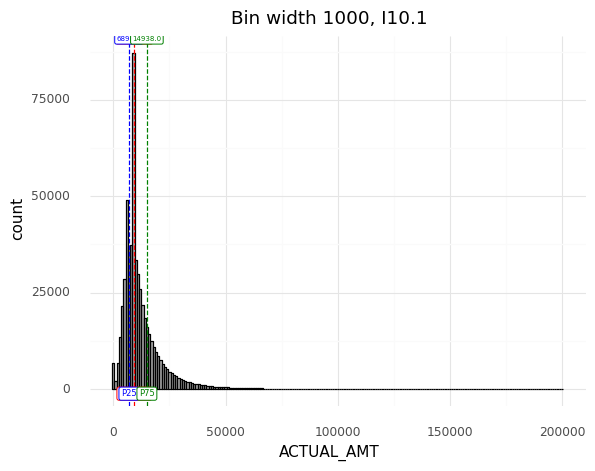

<ggplot: (129201044086)>

In [47]:
med_code = 'I10.1'
amt_field = 'ACTUAL_AMT'
upper_lim = 200000
lower_lim = 1
bin_width = 1000

dframe = pd.read_csv(os.path.join(directory + med_code + '.csv'), low_memory=False)

df2 = dframe[(dframe[amt_field] <= upper_lim) & \
          (~dframe[amt_field].isna()) & \
          (dframe[amt_field] >= lower_lim)][amt_field].to_frame()

med_value = df2[amt_field].median()
q_25 = df2[amt_field].quantile(0.25)
q_75 = df2[amt_field].quantile(0.75)
max_val = len(df2[amt_field])
graph_title = 'Bin width 1000, ' + med_code

p = ggplot(aes(x=amt_field), data=df2)
p + geom_histogram(binwidth=bin_width, 
#                    fill='blue',     # fill color
#                    breaks=list(np.arange(0, 100000, 2000)),
                   colour='black', # outline color
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(graph_title) \
    + geom_vline(
        mapping = aes(xintercept = med_value),
        linetype = "dashed",
        color = "red",
        size = 0.5
        ) \
    + annotate('label',x=med_value, y=math.inf, size=5, color='red', va='top', label=med_value) \
    + annotate('label',x=med_value, y=0, size=6, color='red', va='top', label='Median') \
    + geom_vline(
        mapping = aes(xintercept = q_25),
        linetype = "dashed",
        color = "blue",
        size = 0.5
        ) \
    + annotate('label',x=q_25, y=math.inf, size=5, color='blue', va='top', label=q_25) \
    + annotate('label',x=q_25, y=0, size=6, color='blue', va='top', label='P25') \
    + geom_vline(
        mapping = aes(xintercept = q_75),
        linetype = "dashed",
        color = "green",
        size = 0.5
        ) \
    + annotate('label',x=q_75, y=math.inf, size=5, color='green', va='top', label=q_75) \
    + annotate('label',x=q_75, y=0, size=6, color='green', va='top', label='P75') \
    + theme_minimal()

# for i in range(length_list):
#     df_input = pd.read_csv(os.path.join(directory + files_med_proc[i] + '.csv'), low_memory=False)
#     plot_histo(df_input, 'ACTUAL_AMT', 100000.0, 1.0, 1000, 'Bin width 1000' + files_med_proc[i])    

### I10.9

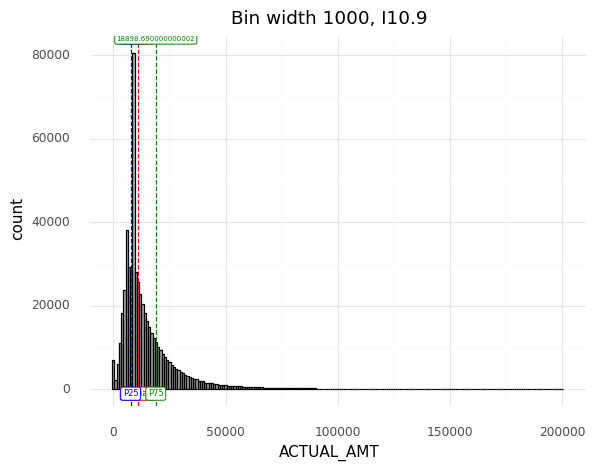

<ggplot: (129201258186)>

In [48]:
med_code = 'I10.9'
amt_field = 'ACTUAL_AMT'
upper_lim = 200000
lower_lim = 1
bin_width = 1000

dframe = pd.read_csv(os.path.join(directory + med_code + '.csv'), low_memory=False)

df2 = dframe[(dframe[amt_field] <= upper_lim) & \
          (~dframe[amt_field].isna()) & \
          (dframe[amt_field] >= lower_lim)][amt_field].to_frame()

med_value = df2[amt_field].median()
q_25 = df2[amt_field].quantile(0.25)
q_75 = df2[amt_field].quantile(0.75)
max_val = len(df2[amt_field])
graph_title = 'Bin width 1000, ' + med_code

p = ggplot(aes(x=amt_field), data=df2)
p + geom_histogram(binwidth=bin_width, 
#                    fill='blue',     # fill color
#                    breaks=list(np.arange(0, 100000, 2000)),
                   colour='black', # outline color
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(graph_title) \
    + geom_vline(
        mapping = aes(xintercept = med_value),
        linetype = "dashed",
        color = "red",
        size = 0.5
        ) \
    + annotate('label',x=med_value, y=math.inf, size=5, color='red', va='top', label=med_value) \
    + annotate('label',x=med_value, y=0, size=6, color='red', va='top', label='Median') \
    + geom_vline(
        mapping = aes(xintercept = q_25),
        linetype = "dashed",
        color = "blue",
        size = 0.5
        ) \
    + annotate('label',x=q_25, y=math.inf, size=5, color='blue', va='top', label=q_25) \
    + annotate('label',x=q_25, y=0, size=6, color='blue', va='top', label='P25') \
    + geom_vline(
        mapping = aes(xintercept = q_75),
        linetype = "dashed",
        color = "green",
        size = 0.5
        ) \
    + annotate('label',x=q_75, y=math.inf, size=5, color='green', va='top', label=q_75) \
    + annotate('label',x=q_75, y=0, size=6, color='green', va='top', label='P75') \
    + theme_minimal()

# for i in range(length_list):
#     df_input = pd.read_csv(os.path.join(directory + files_med_proc[i] + '.csv'), low_memory=False)
#     plot_histo(df_input, 'ACTUAL_AMT', 100000.0, 1.0, 1000, 'Bin width 1000' + files_med_proc[i])    

### J18.92

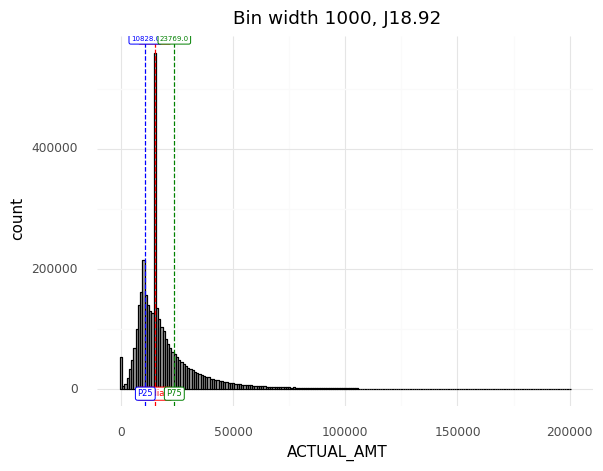

<ggplot: (129199868498)>

In [49]:
med_code = 'J18.92'
amt_field = 'ACTUAL_AMT'
upper_lim = 200000
lower_lim = 1
bin_width = 1000

dframe = pd.read_csv(os.path.join(directory + med_code + '.csv'), low_memory=False)

df2 = dframe[(dframe[amt_field] <= upper_lim) & \
          (~dframe[amt_field].isna()) & \
          (dframe[amt_field] >= lower_lim)][amt_field].to_frame()

med_value = df2[amt_field].median()
q_25 = df2[amt_field].quantile(0.25)
q_75 = df2[amt_field].quantile(0.75)
max_val = len(df2[amt_field])
graph_title = 'Bin width 1000, ' + med_code

p = ggplot(aes(x=amt_field), data=df2)
p + geom_histogram(binwidth=bin_width, 
#                    fill='blue',     # fill color
#                    breaks=list(np.arange(0, 100000, 2000)),
                   colour='black', # outline color
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(graph_title) \
    + geom_vline(
        mapping = aes(xintercept = med_value),
        linetype = "dashed",
        color = "red",
        size = 0.5
        ) \
    + annotate('label',x=med_value, y=math.inf, size=5, color='red', va='top', label=med_value) \
    + annotate('label',x=med_value, y=0, size=6, color='red', va='top', label='Median') \
    + geom_vline(
        mapping = aes(xintercept = q_25),
        linetype = "dashed",
        color = "blue",
        size = 0.5
        ) \
    + annotate('label',x=q_25, y=math.inf, size=5, color='blue', va='top', label=q_25) \
    + annotate('label',x=q_25, y=0, size=6, color='blue', va='top', label='P25') \
    + geom_vline(
        mapping = aes(xintercept = q_75),
        linetype = "dashed",
        color = "green",
        size = 0.5
        ) \
    + annotate('label',x=q_75, y=math.inf, size=5, color='green', va='top', label=q_75) \
    + annotate('label',x=q_75, y=0, size=6, color='green', va='top', label='P75') \
    + theme_minimal()

# for i in range(length_list):
#     df_input = pd.read_csv(os.path.join(directory + files_med_proc[i] + '.csv'), low_memory=False)
#     plot_histo(df_input, 'ACTUAL_AMT', 100000.0, 1.0, 1000, 'Bin width 1000' + files_med_proc[i])    

### J45.90

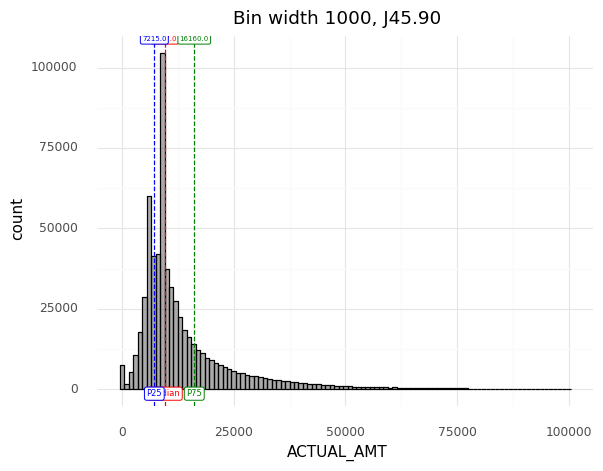

<ggplot: (129199908560)>

In [50]:
med_code = 'J45.90'
amt_field = 'ACTUAL_AMT'
upper_lim = 100000
lower_lim = 1
bin_width = 1000

dframe = pd.read_csv(os.path.join(directory + med_code + '.csv'), low_memory=False)

df2 = dframe[(dframe[amt_field] <= upper_lim) & \
          (~dframe[amt_field].isna()) & \
          (dframe[amt_field] >= lower_lim)][amt_field].to_frame()

med_value = df2[amt_field].median()
q_25 = df2[amt_field].quantile(0.25)
q_75 = df2[amt_field].quantile(0.75)
max_val = len(df2[amt_field])
graph_title = 'Bin width 1000, ' + med_code

p = ggplot(aes(x=amt_field), data=df2)
p + geom_histogram(binwidth=bin_width, 
#                    fill='blue',     # fill color
#                    breaks=list(np.arange(0, 100000, 2000)),
                   colour='black', # outline color
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(graph_title) \
    + geom_vline(
        mapping = aes(xintercept = med_value),
        linetype = "dashed",
        color = "red",
        size = 0.5
        ) \
    + annotate('label',x=med_value, y=math.inf, size=5, color='red', va='top', label=med_value) \
    + annotate('label',x=med_value, y=0, size=6, color='red', va='top', label='Median') \
    + geom_vline(
        mapping = aes(xintercept = q_25),
        linetype = "dashed",
        color = "blue",
        size = 0.5
        ) \
    + annotate('label',x=q_25, y=math.inf, size=5, color='blue', va='top', label=q_25) \
    + annotate('label',x=q_25, y=0, size=6, color='blue', va='top', label='P25') \
    + geom_vline(
        mapping = aes(xintercept = q_75),
        linetype = "dashed",
        color = "green",
        size = 0.5
        ) \
    + annotate('label',x=q_75, y=math.inf, size=5, color='green', va='top', label=q_75) \
    + annotate('label',x=q_75, y=0, size=6, color='green', va='top', label='P75') \
    + theme_minimal()

# for i in range(length_list):
#     df_input = pd.read_csv(os.path.join(directory + files_med_proc[i] + '.csv'), low_memory=False)
#     plot_histo(df_input, 'ACTUAL_AMT', 100000.0, 1.0, 1000, 'Bin width 1000' + files_med_proc[i])    

### K29.1

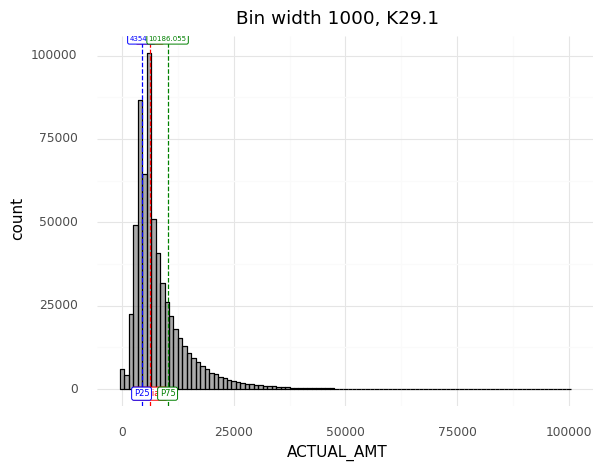

<ggplot: (129201118742)>

In [51]:
med_code = 'K29.1'
amt_field = 'ACTUAL_AMT'
upper_lim = 100000
lower_lim = 1
bin_width = 1000

dframe = pd.read_csv(os.path.join(directory + med_code + '.csv'), low_memory=False)

df2 = dframe[(dframe[amt_field] <= upper_lim) & \
          (~dframe[amt_field].isna()) & \
          (dframe[amt_field] >= lower_lim)][amt_field].to_frame()

med_value = df2[amt_field].median()
q_25 = df2[amt_field].quantile(0.25)
q_75 = df2[amt_field].quantile(0.75)
max_val = len(df2[amt_field])
graph_title = 'Bin width 1000, ' + med_code

p = ggplot(aes(x=amt_field), data=df2)
p + geom_histogram(binwidth=bin_width, 
#                    fill='blue',     # fill color
#                    breaks=list(np.arange(0, 100000, 2000)),
                   colour='black', # outline color
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(graph_title) \
    + geom_vline(
        mapping = aes(xintercept = med_value),
        linetype = "dashed",
        color = "red",
        size = 0.5
        ) \
    + annotate('label',x=med_value, y=math.inf, size=5, color='red', va='top', label=med_value) \
    + annotate('label',x=med_value, y=0, size=6, color='red', va='top', label='Median') \
    + geom_vline(
        mapping = aes(xintercept = q_25),
        linetype = "dashed",
        color = "blue",
        size = 0.5
        ) \
    + annotate('label',x=q_25, y=math.inf, size=5, color='blue', va='top', label=q_25) \
    + annotate('label',x=q_25, y=0, size=6, color='blue', va='top', label='P25') \
    + geom_vline(
        mapping = aes(xintercept = q_75),
        linetype = "dashed",
        color = "green",
        size = 0.5
        ) \
    + annotate('label',x=q_75, y=math.inf, size=5, color='green', va='top', label=q_75) \
    + annotate('label',x=q_75, y=0, size=6, color='green', va='top', label='P75') \
    + theme_minimal()

# for i in range(length_list):
#     df_input = pd.read_csv(os.path.join(directory + files_med_proc[i] + '.csv'), low_memory=False)
#     plot_histo(df_input, 'ACTUAL_AMT', 100000.0, 1.0, 1000, 'Bin width 1000' + files_med_proc[i])    

### N18.0

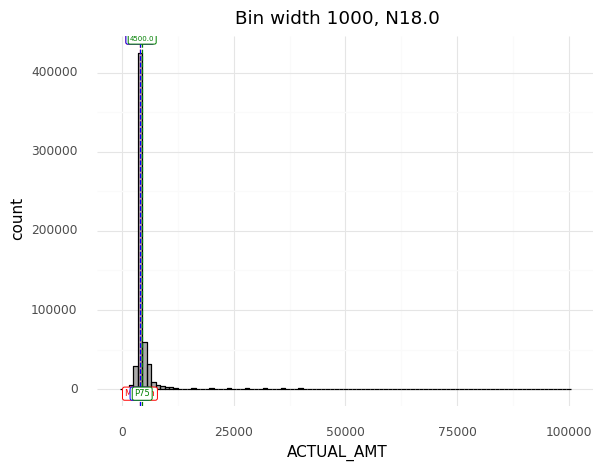

<ggplot: (129199920701)>

In [52]:
med_code = 'N18.0'
amt_field = 'ACTUAL_AMT'
upper_lim = 100000
lower_lim = 1
bin_width = 1000

dframe = pd.read_csv(os.path.join(directory + med_code + '.csv'), low_memory=False)

df2 = dframe[(dframe[amt_field] <= upper_lim) & \
          (~dframe[amt_field].isna()) & \
          (dframe[amt_field] >= lower_lim)][amt_field].to_frame()

med_value = df2[amt_field].median()
q_25 = df2[amt_field].quantile(0.25)
q_75 = df2[amt_field].quantile(0.75)
max_val = len(df2[amt_field])
graph_title = 'Bin width 1000, ' + med_code

p = ggplot(aes(x=amt_field), data=df2)
p + geom_histogram(binwidth=bin_width, 
#                    fill='blue',     # fill color
#                    breaks=list(np.arange(0, 100000, 2000)),
                   colour='black', # outline color
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(graph_title) \
    + geom_vline(
        mapping = aes(xintercept = med_value),
        linetype = "dashed",
        color = "red",
        size = 0.5
        ) \
    + annotate('label',x=med_value, y=math.inf, size=5, color='red', va='top', label=med_value) \
    + annotate('label',x=med_value, y=0, size=6, color='red', va='top', label='Median') \
    + geom_vline(
        mapping = aes(xintercept = q_25),
        linetype = "dashed",
        color = "blue",
        size = 0.5
        ) \
    + annotate('label',x=q_25, y=math.inf, size=5, color='blue', va='top', label=q_25) \
    + annotate('label',x=q_25, y=0, size=6, color='blue', va='top', label='P25') \
    + geom_vline(
        mapping = aes(xintercept = q_75),
        linetype = "dashed",
        color = "green",
        size = 0.5
        ) \
    + annotate('label',x=q_75, y=math.inf, size=5, color='green', va='top', label=q_75) \
    + annotate('label',x=q_75, y=0, size=6, color='green', va='top', label='P75') \
    + theme_minimal()

# for i in range(length_list):
#     df_input = pd.read_csv(os.path.join(directory + files_med_proc[i] + '.csv'), low_memory=False)
#     plot_histo(df_input, 'ACTUAL_AMT', 100000.0, 1.0, 1000, 'Bin width 1000' + files_med_proc[i])    

### N39.0

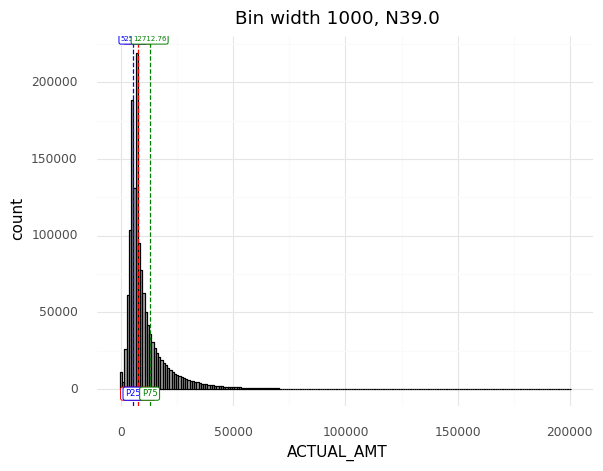

<ggplot: (129200106569)>

In [53]:
med_code = 'N39.0'
amt_field = 'ACTUAL_AMT'
upper_lim = 200000
lower_lim = 1
bin_width = 1000

dframe = pd.read_csv(os.path.join(directory + med_code + '.csv'), low_memory=False)

df2 = dframe[(dframe[amt_field] <= upper_lim) & \
          (~dframe[amt_field].isna()) & \
          (dframe[amt_field] >= lower_lim)][amt_field].to_frame()

med_value = df2[amt_field].median()
q_25 = df2[amt_field].quantile(0.25)
q_75 = df2[amt_field].quantile(0.75)
max_val = len(df2[amt_field])
graph_title = 'Bin width 1000, ' + med_code

p = ggplot(aes(x=amt_field), data=df2)
p + geom_histogram(binwidth=bin_width, 
#                    fill='blue',     # fill color
#                    breaks=list(np.arange(0, 100000, 2000)),
                   colour='black', # outline color
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(graph_title) \
    + geom_vline(
        mapping = aes(xintercept = med_value),
        linetype = "dashed",
        color = "red",
        size = 0.5
        ) \
    + annotate('label',x=med_value, y=math.inf, size=5, color='red', va='top', label=med_value) \
    + annotate('label',x=med_value, y=0, size=6, color='red', va='top', label='Median') \
    + geom_vline(
        mapping = aes(xintercept = q_25),
        linetype = "dashed",
        color = "blue",
        size = 0.5
        ) \
    + annotate('label',x=q_25, y=math.inf, size=5, color='blue', va='top', label=q_25) \
    + annotate('label',x=q_25, y=0, size=6, color='blue', va='top', label='P25') \
    + geom_vline(
        mapping = aes(xintercept = q_75),
        linetype = "dashed",
        color = "green",
        size = 0.5
        ) \
    + annotate('label',x=q_75, y=math.inf, size=5, color='green', va='top', label=q_75) \
    + annotate('label',x=q_75, y=0, size=6, color='green', va='top', label='P75') \
    + theme_minimal()

# for i in range(length_list):
#     df_input = pd.read_csv(os.path.join(directory + files_med_proc[i] + '.csv'), low_memory=False)
#     plot_histo(df_input, 'ACTUAL_AMT', 100000.0, 1.0, 1000, 'Bin width 1000' + files_med_proc[i])    

### P36.9

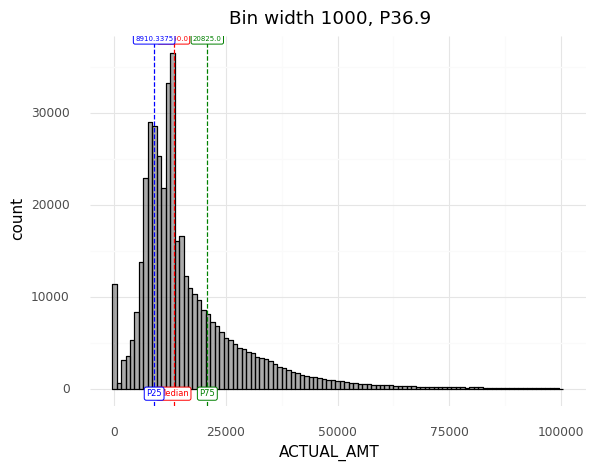

<ggplot: (129231070419)>

In [54]:
med_code = 'P36.9'
amt_field = 'ACTUAL_AMT'
upper_lim = 100000
lower_lim = 1
bin_width = 1000

dframe = pd.read_csv(os.path.join(directory + med_code + '.csv'), low_memory=False)

df2 = dframe[(dframe[amt_field] <= upper_lim) & \
          (~dframe[amt_field].isna()) & \
          (dframe[amt_field] >= lower_lim)][amt_field].to_frame()

med_value = df2[amt_field].median()
q_25 = df2[amt_field].quantile(0.25)
q_75 = df2[amt_field].quantile(0.75)
max_val = len(df2[amt_field])
graph_title = 'Bin width 1000, ' + med_code

p = ggplot(aes(x=amt_field), data=df2)
p + geom_histogram(binwidth=bin_width, 
#                    fill='blue',     # fill color
#                    breaks=list(np.arange(0, 100000, 2000)),
                   colour='black', # outline color
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(graph_title) \
    + geom_vline(
        mapping = aes(xintercept = med_value),
        linetype = "dashed",
        color = "red",
        size = 0.5
        ) \
    + annotate('label',x=med_value, y=math.inf, size=5, color='red', va='top', label=med_value) \
    + annotate('label',x=med_value, y=0, size=6, color='red', va='top', label='Median') \
    + geom_vline(
        mapping = aes(xintercept = q_25),
        linetype = "dashed",
        color = "blue",
        size = 0.5
        ) \
    + annotate('label',x=q_25, y=math.inf, size=5, color='blue', va='top', label=q_25) \
    + annotate('label',x=q_25, y=0, size=6, color='blue', va='top', label='P25') \
    + geom_vline(
        mapping = aes(xintercept = q_75),
        linetype = "dashed",
        color = "green",
        size = 0.5
        ) \
    + annotate('label',x=q_75, y=math.inf, size=5, color='green', va='top', label=q_75) \
    + annotate('label',x=q_75, y=0, size=6, color='green', va='top', label='P75') \
    + theme_minimal()

# for i in range(length_list):
#     df_input = pd.read_csv(os.path.join(directory + files_med_proc[i] + '.csv'), low_memory=False)
#     plot_histo(df_input, 'ACTUAL_AMT', 100000.0, 1.0, 1000, 'Bin width 1000' + files_med_proc[i])    

## Proc Plots

### 58120

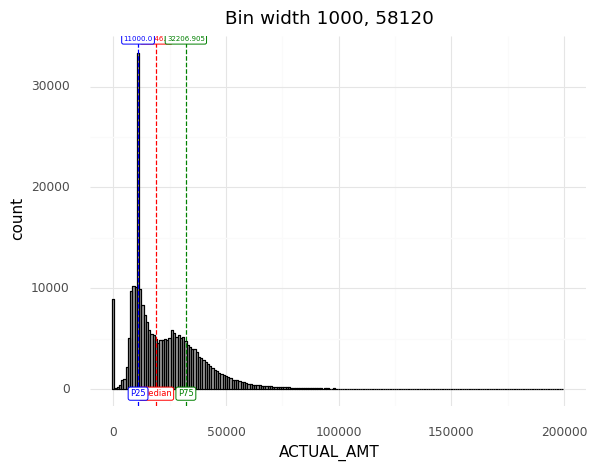

<ggplot: (129200111168)>

In [55]:
med_code = '58120'
amt_field = 'ACTUAL_AMT'
upper_lim = 200000
lower_lim = 1
bin_width = 1000

dframe = pd.read_csv(os.path.join(directory + med_code + '.csv'), low_memory=False)

df2 = dframe[(dframe[amt_field] <= upper_lim) & \
          (~dframe[amt_field].isna()) & \
          (dframe[amt_field] >= lower_lim)][amt_field].to_frame()

med_value = df2[amt_field].median()
q_25 = df2[amt_field].quantile(0.25)
q_75 = df2[amt_field].quantile(0.75)
max_val = len(df2[amt_field])
graph_title = 'Bin width 1000, ' + med_code

p = ggplot(aes(x=amt_field), data=df2)
p + geom_histogram(binwidth=bin_width, 
#                    fill='blue',     # fill color
#                    breaks=list(np.arange(0, 100000, 2000)),
                   colour='black', # outline color
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(graph_title) \
    + geom_vline(
        mapping = aes(xintercept = med_value),
        linetype = "dashed",
        color = "red",
        size = 0.5
        ) \
    + annotate('label',x=med_value, y=math.inf, size=5, color='red', va='top', label=med_value) \
    + annotate('label',x=med_value, y=0, size=6, color='red', va='top', label='Median') \
    + geom_vline(
        mapping = aes(xintercept = q_25),
        linetype = "dashed",
        color = "blue",
        size = 0.5
        ) \
    + annotate('label',x=q_25, y=math.inf, size=5, color='blue', va='top', label=q_25) \
    + annotate('label',x=q_25, y=0, size=6, color='blue', va='top', label='P25') \
    + geom_vline(
        mapping = aes(xintercept = q_75),
        linetype = "dashed",
        color = "green",
        size = 0.5
        ) \
    + annotate('label',x=q_75, y=math.inf, size=5, color='green', va='top', label=q_75) \
    + annotate('label',x=q_75, y=0, size=6, color='green', va='top', label='P75') \
    + theme_minimal()

# for i in range(length_list):
#     df_input = pd.read_csv(os.path.join(directory + files_med_proc[i] + '.csv'), low_memory=False)
#     plot_histo(df_input, 'ACTUAL_AMT', 100000.0, 1.0, 1000, 'Bin width 1000' + files_med_proc[i])    

### 59409

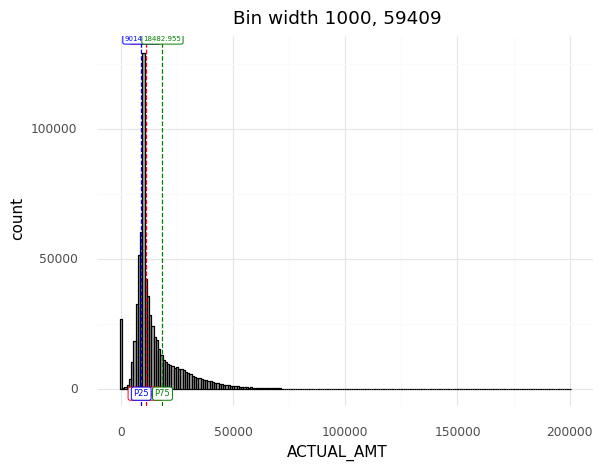

<ggplot: (129201216787)>

In [56]:
med_code = '59409'
amt_field = 'ACTUAL_AMT'
upper_lim = 200000
lower_lim = 1
bin_width = 1000

dframe = pd.read_csv(os.path.join(directory + med_code + '.csv'), low_memory=False)

df2 = dframe[(dframe[amt_field] <= upper_lim) & \
          (~dframe[amt_field].isna()) & \
          (dframe[amt_field] >= lower_lim)][amt_field].to_frame()

med_value = df2[amt_field].median()
q_25 = df2[amt_field].quantile(0.25)
q_75 = df2[amt_field].quantile(0.75)
max_val = len(df2[amt_field])
graph_title = 'Bin width 1000, ' + med_code

p = ggplot(aes(x=amt_field), data=df2)
p + geom_histogram(binwidth=bin_width, 
#                    fill='blue',     # fill color
#                    breaks=list(np.arange(0, 100000, 2000)),
                   colour='black', # outline color
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(graph_title) \
    + geom_vline(
        mapping = aes(xintercept = med_value),
        linetype = "dashed",
        color = "red",
        size = 0.5
        ) \
    + annotate('label',x=med_value, y=math.inf, size=5, color='red', va='top', label=med_value) \
    + annotate('label',x=med_value, y=0, size=6, color='red', va='top', label='Median') \
    + geom_vline(
        mapping = aes(xintercept = q_25),
        linetype = "dashed",
        color = "blue",
        size = 0.5
        ) \
    + annotate('label',x=q_25, y=math.inf, size=5, color='blue', va='top', label=q_25) \
    + annotate('label',x=q_25, y=0, size=6, color='blue', va='top', label='P25') \
    + geom_vline(
        mapping = aes(xintercept = q_75),
        linetype = "dashed",
        color = "green",
        size = 0.5
        ) \
    + annotate('label',x=q_75, y=math.inf, size=5, color='green', va='top', label=q_75) \
    + annotate('label',x=q_75, y=0, size=6, color='green', va='top', label='P75') \
    + theme_minimal()

# for i in range(length_list):
#     df_input = pd.read_csv(os.path.join(directory + files_med_proc[i] + '.csv'), low_memory=False)
#     plot_histo(df_input, 'ACTUAL_AMT', 100000.0, 1.0, 1000, 'Bin width 1000' + files_med_proc[i])    

### 59513

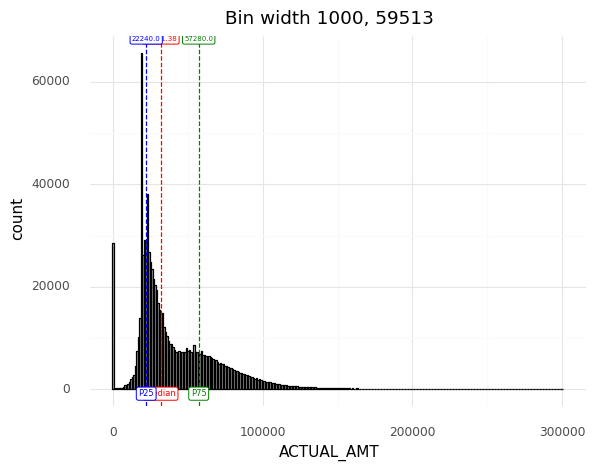

<ggplot: (129201206230)>

In [57]:
med_code = '59513'
amt_field = 'ACTUAL_AMT'
upper_lim = 300000
lower_lim = 1
bin_width = 1000

dframe = pd.read_csv(os.path.join(directory + med_code + '.csv'), low_memory=False)

df2 = dframe[(dframe[amt_field] <= upper_lim) & \
          (~dframe[amt_field].isna()) & \
          (dframe[amt_field] >= lower_lim)][amt_field].to_frame()

med_value = df2[amt_field].median()
q_25 = df2[amt_field].quantile(0.25)
q_75 = df2[amt_field].quantile(0.75)
max_val = len(df2[amt_field])
graph_title = 'Bin width 1000, ' + med_code

p = ggplot(aes(x=amt_field), data=df2)
p + geom_histogram(binwidth=bin_width, 
#                    fill='blue',     # fill color
#                    breaks=list(np.arange(0, 100000, 2000)),
                   colour='black', # outline color
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(graph_title) \
    + geom_vline(
        mapping = aes(xintercept = med_value),
        linetype = "dashed",
        color = "red",
        size = 0.5
        ) \
    + annotate('label',x=med_value, y=math.inf, size=5, color='red', va='top', label=med_value) \
    + annotate('label',x=med_value, y=0, size=6, color='red', va='top', label='Median') \
    + geom_vline(
        mapping = aes(xintercept = q_25),
        linetype = "dashed",
        color = "blue",
        size = 0.5
        ) \
    + annotate('label',x=q_25, y=math.inf, size=5, color='blue', va='top', label=q_25) \
    + annotate('label',x=q_25, y=0, size=6, color='blue', va='top', label='P25') \
    + geom_vline(
        mapping = aes(xintercept = q_75),
        linetype = "dashed",
        color = "green",
        size = 0.5
        ) \
    + annotate('label',x=q_75, y=math.inf, size=5, color='green', va='top', label=q_75) \
    + annotate('label',x=q_75, y=0, size=6, color='green', va='top', label='P75') \
    + theme_minimal()

# for i in range(length_list):
#     df_input = pd.read_csv(os.path.join(directory + files_med_proc[i] + '.csv'), low_memory=False)
#     plot_histo(df_input, 'ACTUAL_AMT', 100000.0, 1.0, 1000, 'Bin width 1000' + files_med_proc[i])    

### 59514

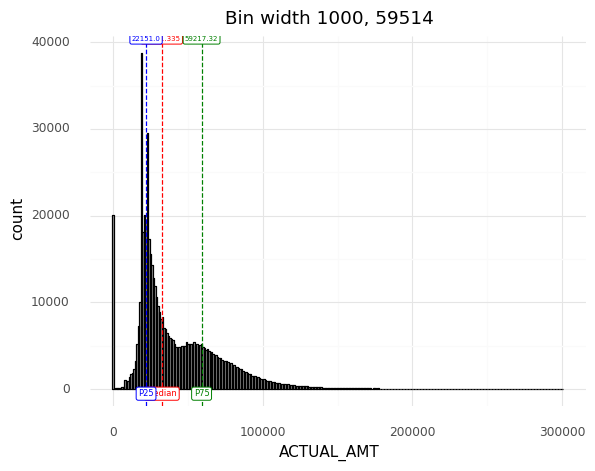

<ggplot: (129202260962)>

In [58]:
med_code = '59514'
amt_field = 'ACTUAL_AMT'
upper_lim = 300000
lower_lim = 1
bin_width = 1000

dframe = pd.read_csv(os.path.join(directory + med_code + '.csv'), low_memory=False)

df2 = dframe[(dframe[amt_field] <= upper_lim) & \
          (~dframe[amt_field].isna()) & \
          (dframe[amt_field] >= lower_lim)][amt_field].to_frame()

med_value = df2[amt_field].median()
q_25 = df2[amt_field].quantile(0.25)
q_75 = df2[amt_field].quantile(0.75)
max_val = len(df2[amt_field])
graph_title = 'Bin width 1000, ' + med_code

p = ggplot(aes(x=amt_field), data=df2)
p + geom_histogram(binwidth=bin_width, 
#                    fill='blue',     # fill color
#                    breaks=list(np.arange(0, 100000, 2000)),
                   colour='black', # outline color
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(graph_title) \
    + geom_vline(
        mapping = aes(xintercept = med_value),
        linetype = "dashed",
        color = "red",
        size = 0.5
        ) \
    + annotate('label',x=med_value, y=math.inf, size=5, color='red', va='top', label=med_value) \
    + annotate('label',x=med_value, y=0, size=6, color='red', va='top', label='Median') \
    + geom_vline(
        mapping = aes(xintercept = q_25),
        linetype = "dashed",
        color = "blue",
        size = 0.5
        ) \
    + annotate('label',x=q_25, y=math.inf, size=5, color='blue', va='top', label=q_25) \
    + annotate('label',x=q_25, y=0, size=6, color='blue', va='top', label='P25') \
    + geom_vline(
        mapping = aes(xintercept = q_75),
        linetype = "dashed",
        color = "green",
        size = 0.5
        ) \
    + annotate('label',x=q_75, y=math.inf, size=5, color='green', va='top', label=q_75) \
    + annotate('label',x=q_75, y=0, size=6, color='green', va='top', label='P75') \
    + theme_minimal()

# for i in range(length_list):
#     df_input = pd.read_csv(os.path.join(directory + files_med_proc[i] + '.csv'), low_memory=False)
#     plot_histo(df_input, 'ACTUAL_AMT', 100000.0, 1.0, 1000, 'Bin width 1000' + files_med_proc[i])    

### 66987

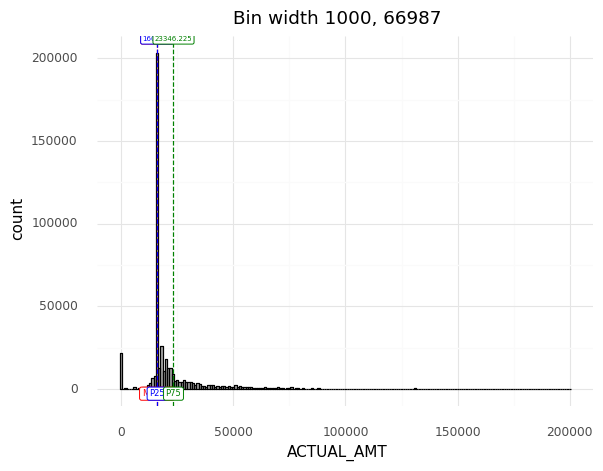

<ggplot: (129200527153)>

In [59]:
med_code = '66987'
amt_field = 'ACTUAL_AMT'
upper_lim = 200000
lower_lim = 1
bin_width = 1000

dframe = pd.read_csv(os.path.join(directory + med_code + '.csv'), low_memory=False)

df2 = dframe[(dframe[amt_field] <= upper_lim) & \
          (~dframe[amt_field].isna()) & \
          (dframe[amt_field] >= lower_lim)][amt_field].to_frame()

med_value = df2[amt_field].median()
q_25 = df2[amt_field].quantile(0.25)
q_75 = df2[amt_field].quantile(0.75)
max_val = len(df2[amt_field])
graph_title = 'Bin width 1000, ' + med_code

p = ggplot(aes(x=amt_field), data=df2)
p + geom_histogram(binwidth=bin_width, 
#                    fill='blue',     # fill color
#                    breaks=list(np.arange(0, 100000, 2000)),
                   colour='black', # outline color
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(graph_title) \
    + geom_vline(
        mapping = aes(xintercept = med_value),
        linetype = "dashed",
        color = "red",
        size = 0.5
        ) \
    + annotate('label',x=med_value, y=math.inf, size=5, color='red', va='top', label=med_value) \
    + annotate('label',x=med_value, y=0, size=6, color='red', va='top', label='Median') \
    + geom_vline(
        mapping = aes(xintercept = q_25),
        linetype = "dashed",
        color = "blue",
        size = 0.5
        ) \
    + annotate('label',x=q_25, y=math.inf, size=5, color='blue', va='top', label=q_25) \
    + annotate('label',x=q_25, y=0, size=6, color='blue', va='top', label='P25') \
    + geom_vline(
        mapping = aes(xintercept = q_75),
        linetype = "dashed",
        color = "green",
        size = 0.5
        ) \
    + annotate('label',x=q_75, y=math.inf, size=5, color='green', va='top', label=q_75) \
    + annotate('label',x=q_75, y=0, size=6, color='green', va='top', label='P75') \
    + theme_minimal()

# for i in range(length_list):
#     df_input = pd.read_csv(os.path.join(directory + files_med_proc[i] + '.csv'), low_memory=False)
#     plot_histo(df_input, 'ACTUAL_AMT', 100000.0, 1.0, 1000, 'Bin width 1000' + files_med_proc[i])    

### 77401

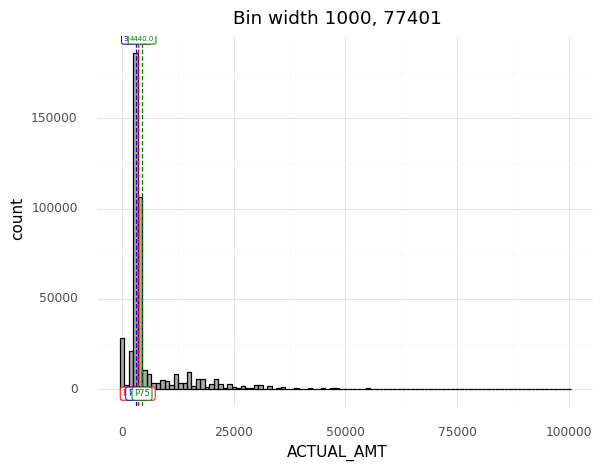

<ggplot: (129200870566)>

In [60]:
med_code = '77401'
amt_field = 'ACTUAL_AMT'
upper_lim = 100000
lower_lim = 1
bin_width = 1000

dframe = pd.read_csv(os.path.join(directory + med_code + '.csv'), low_memory=False)

df2 = dframe[(dframe[amt_field] <= upper_lim) & \
          (~dframe[amt_field].isna()) & \
          (dframe[amt_field] >= lower_lim)][amt_field].to_frame()

med_value = df2[amt_field].median()
q_25 = df2[amt_field].quantile(0.25)
q_75 = df2[amt_field].quantile(0.75)
max_val = len(df2[amt_field])
graph_title = 'Bin width 1000, ' + med_code

p = ggplot(aes(x=amt_field), data=df2)
p + geom_histogram(binwidth=bin_width, 
#                    fill='blue',     # fill color
#                    breaks=list(np.arange(0, 100000, 2000)),
                   colour='black', # outline color
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(graph_title) \
    + geom_vline(
        mapping = aes(xintercept = med_value),
        linetype = "dashed",
        color = "red",
        size = 0.5
        ) \
    + annotate('label',x=med_value, y=math.inf, size=5, color='red', va='top', label=med_value) \
    + annotate('label',x=med_value, y=0, size=6, color='red', va='top', label='Median') \
    + geom_vline(
        mapping = aes(xintercept = q_25),
        linetype = "dashed",
        color = "blue",
        size = 0.5
        ) \
    + annotate('label',x=q_25, y=math.inf, size=5, color='blue', va='top', label=q_25) \
    + annotate('label',x=q_25, y=0, size=6, color='blue', va='top', label='P25') \
    + geom_vline(
        mapping = aes(xintercept = q_75),
        linetype = "dashed",
        color = "green",
        size = 0.5
        ) \
    + annotate('label',x=q_75, y=math.inf, size=5, color='green', va='top', label=q_75) \
    + annotate('label',x=q_75, y=0, size=6, color='green', va='top', label='P75') \
    + theme_minimal()

# for i in range(length_list):
#     df_input = pd.read_csv(os.path.join(directory + files_med_proc[i] + '.csv'), low_memory=False)
#     plot_histo(df_input, 'ACTUAL_AMT', 100000.0, 1.0, 1000, 'Bin width 1000' + files_med_proc[i])    

### 90935

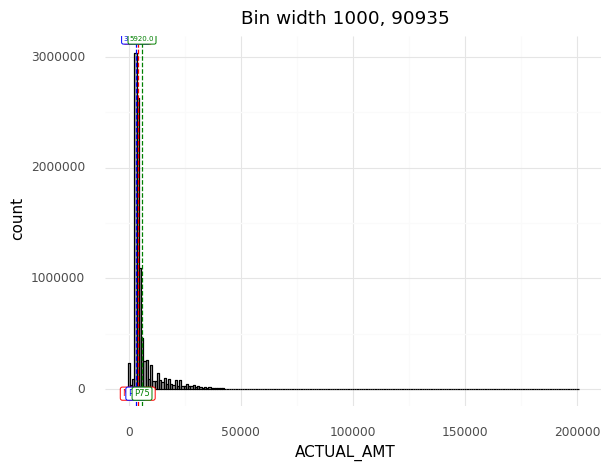

<ggplot: (129200480007)>

In [61]:
med_code = '90935'
amt_field = 'ACTUAL_AMT'
upper_lim = 200000
lower_lim = 1
bin_width = 1000

dframe = pd.read_csv(os.path.join(directory + med_code + '.csv'), low_memory=False)

df2 = dframe[(dframe[amt_field] <= upper_lim) & \
          (~dframe[amt_field].isna()) & \
          (dframe[amt_field] >= lower_lim)][amt_field].to_frame()

med_value = df2[amt_field].median()
q_25 = df2[amt_field].quantile(0.25)
q_75 = df2[amt_field].quantile(0.75)
max_val = len(df2[amt_field])
graph_title = 'Bin width 1000, ' + med_code

p = ggplot(aes(x=amt_field), data=df2)
p + geom_histogram(binwidth=bin_width, 
#                    fill='blue',     # fill color
#                    breaks=list(np.arange(0, 100000, 2000)),
                   colour='black', # outline color
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(graph_title) \
    + geom_vline(
        mapping = aes(xintercept = med_value),
        linetype = "dashed",
        color = "red",
        size = 0.5
        ) \
    + annotate('label',x=med_value, y=math.inf, size=5, color='red', va='top', label=med_value) \
    + annotate('label',x=med_value, y=0, size=6, color='red', va='top', label='Median') \
    + geom_vline(
        mapping = aes(xintercept = q_25),
        linetype = "dashed",
        color = "blue",
        size = 0.5
        ) \
    + annotate('label',x=q_25, y=math.inf, size=5, color='blue', va='top', label=q_25) \
    + annotate('label',x=q_25, y=0, size=6, color='blue', va='top', label='P25') \
    + geom_vline(
        mapping = aes(xintercept = q_75),
        linetype = "dashed",
        color = "green",
        size = 0.5
        ) \
    + annotate('label',x=q_75, y=math.inf, size=5, color='green', va='top', label=q_75) \
    + annotate('label',x=q_75, y=0, size=6, color='green', va='top', label='P75') \
    + theme_minimal()

# for i in range(length_list):
#     df_input = pd.read_csv(os.path.join(directory + files_med_proc[i] + '.csv'), low_memory=False)
#     plot_histo(df_input, 'ACTUAL_AMT', 100000.0, 1.0, 1000, 'Bin width 1000' + files_med_proc[i])    

### 96408

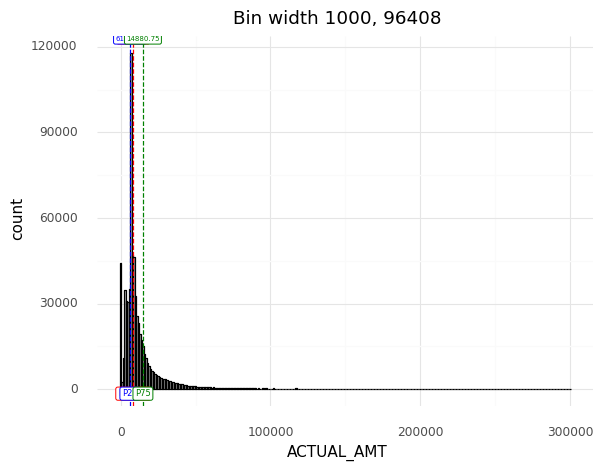

<ggplot: (129231674507)>

In [62]:
med_code = '96408'
amt_field = 'ACTUAL_AMT'
upper_lim = 300000
lower_lim = 1
bin_width = 1000

dframe = pd.read_csv(os.path.join(directory + med_code + '.csv'), low_memory=False)

df2 = dframe[(dframe[amt_field] <= upper_lim) & \
          (~dframe[amt_field].isna()) & \
          (dframe[amt_field] >= lower_lim)][amt_field].to_frame()

med_value = df2[amt_field].median()
q_25 = df2[amt_field].quantile(0.25)
q_75 = df2[amt_field].quantile(0.75)
max_val = len(df2[amt_field])
graph_title = 'Bin width 1000, ' + med_code

p = ggplot(aes(x=amt_field), data=df2)
p + geom_histogram(binwidth=bin_width, 
#                    fill='blue',     # fill color
#                    breaks=list(np.arange(0, 100000, 2000)),
                   colour='black', # outline color
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(graph_title) \
    + geom_vline(
        mapping = aes(xintercept = med_value),
        linetype = "dashed",
        color = "red",
        size = 0.5
        ) \
    + annotate('label',x=med_value, y=math.inf, size=5, color='red', va='top', label=med_value) \
    + annotate('label',x=med_value, y=0, size=6, color='red', va='top', label='Median') \
    + geom_vline(
        mapping = aes(xintercept = q_25),
        linetype = "dashed",
        color = "blue",
        size = 0.5
        ) \
    + annotate('label',x=q_25, y=math.inf, size=5, color='blue', va='top', label=q_25) \
    + annotate('label',x=q_25, y=0, size=6, color='blue', va='top', label='P25') \
    + geom_vline(
        mapping = aes(xintercept = q_75),
        linetype = "dashed",
        color = "green",
        size = 0.5
        ) \
    + annotate('label',x=q_75, y=math.inf, size=5, color='green', va='top', label=q_75) \
    + annotate('label',x=q_75, y=0, size=6, color='green', va='top', label='P75') \
    + theme_minimal()

# for i in range(length_list):
#     df_input = pd.read_csv(os.path.join(directory + files_med_proc[i] + '.csv'), low_memory=False)
#     plot_histo(df_input, 'ACTUAL_AMT', 100000.0, 1.0, 1000, 'Bin width 1000' + files_med_proc[i])    

### 99432

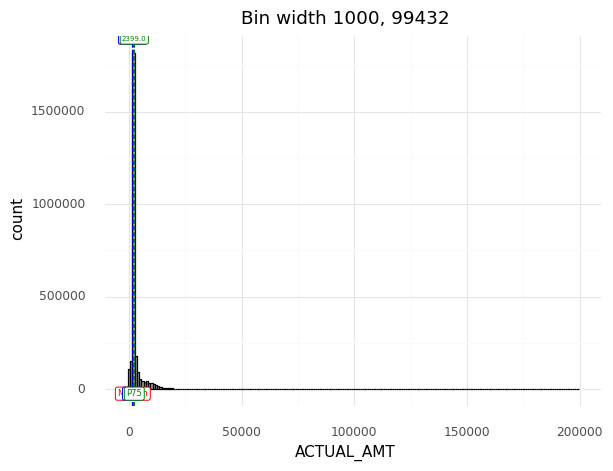

<ggplot: (129201191268)>

In [63]:
med_code = '99432'
amt_field = 'ACTUAL_AMT'
upper_lim = 200000
lower_lim = 1
bin_width = 1000

dframe = pd.read_csv(os.path.join(directory + med_code + '.csv'), low_memory=False)

df2 = dframe[(dframe[amt_field] <= upper_lim) & \
          (~dframe[amt_field].isna()) & \
          (dframe[amt_field] >= lower_lim)][amt_field].to_frame()

med_value = df2[amt_field].median()
q_25 = df2[amt_field].quantile(0.25)
q_75 = df2[amt_field].quantile(0.75)
max_val = len(df2[amt_field])
graph_title = 'Bin width 1000, ' + med_code

p = ggplot(aes(x=amt_field), data=df2)
p + geom_histogram(binwidth=bin_width, 
#                    fill='blue',     # fill color
#                    breaks=list(np.arange(0, 100000, 2000)),
                   colour='black', # outline color
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(graph_title) \
    + geom_vline(
        mapping = aes(xintercept = med_value),
        linetype = "dashed",
        color = "red",
        size = 0.5
        ) \
    + annotate('label',x=med_value, y=math.inf, size=5, color='red', va='top', label=med_value) \
    + annotate('label',x=med_value, y=0, size=6, color='red', va='top', label='Median') \
    + geom_vline(
        mapping = aes(xintercept = q_25),
        linetype = "dashed",
        color = "blue",
        size = 0.5
        ) \
    + annotate('label',x=q_25, y=math.inf, size=5, color='blue', va='top', label=q_25) \
    + annotate('label',x=q_25, y=0, size=6, color='blue', va='top', label='P25') \
    + geom_vline(
        mapping = aes(xintercept = q_75),
        linetype = "dashed",
        color = "green",
        size = 0.5
        ) \
    + annotate('label',x=q_75, y=math.inf, size=5, color='green', va='top', label=q_75) \
    + annotate('label',x=q_75, y=0, size=6, color='green', va='top', label='P75') \
    + theme_minimal()

# for i in range(length_list):
#     df_input = pd.read_csv(os.path.join(directory + files_med_proc[i] + '.csv'), low_memory=False)
#     plot_histo(df_input, 'ACTUAL_AMT', 100000.0, 1.0, 1000, 'Bin width 1000' + files_med_proc[i])    

### 99460

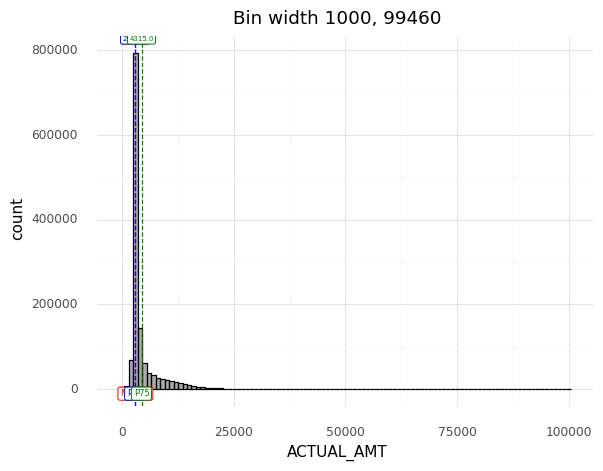

<ggplot: (129198857150)>

In [64]:
med_code = '99460'
amt_field = 'ACTUAL_AMT'
upper_lim = 100000
lower_lim = 1
bin_width = 1000

dframe = pd.read_csv(os.path.join(directory + med_code + '.csv'), low_memory=False)

df2 = dframe[(dframe[amt_field] <= upper_lim) & \
          (~dframe[amt_field].isna()) & \
          (dframe[amt_field] >= lower_lim)][amt_field].to_frame()

med_value = df2[amt_field].median()
q_25 = df2[amt_field].quantile(0.25)
q_75 = df2[amt_field].quantile(0.75)
max_val = len(df2[amt_field])
graph_title = 'Bin width 1000, ' + med_code

p = ggplot(aes(x=amt_field), data=df2)
p + geom_histogram(binwidth=bin_width, 
#                    fill='blue',     # fill color
#                    breaks=list(np.arange(0, 100000, 2000)),
                   colour='black', # outline color
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(graph_title) \
    + geom_vline(
        mapping = aes(xintercept = med_value),
        linetype = "dashed",
        color = "red",
        size = 0.5
        ) \
    + annotate('label',x=med_value, y=math.inf, size=5, color='red', va='top', label=med_value) \
    + annotate('label',x=med_value, y=0, size=6, color='red', va='top', label='Median') \
    + geom_vline(
        mapping = aes(xintercept = q_25),
        linetype = "dashed",
        color = "blue",
        size = 0.5
        ) \
    + annotate('label',x=q_25, y=math.inf, size=5, color='blue', va='top', label=q_25) \
    + annotate('label',x=q_25, y=0, size=6, color='blue', va='top', label='P25') \
    + geom_vline(
        mapping = aes(xintercept = q_75),
        linetype = "dashed",
        color = "green",
        size = 0.5
        ) \
    + annotate('label',x=q_75, y=math.inf, size=5, color='green', va='top', label=q_75) \
    + annotate('label',x=q_75, y=0, size=6, color='green', va='top', label='P75') \
    + theme_minimal()

# for i in range(length_list):
#     df_input = pd.read_csv(os.path.join(directory + files_med_proc[i] + '.csv'), low_memory=False)
#     plot_histo(df_input, 'ACTUAL_AMT', 100000.0, 1.0, 1000, 'Bin width 1000' + files_med_proc[i])    

### MCP01

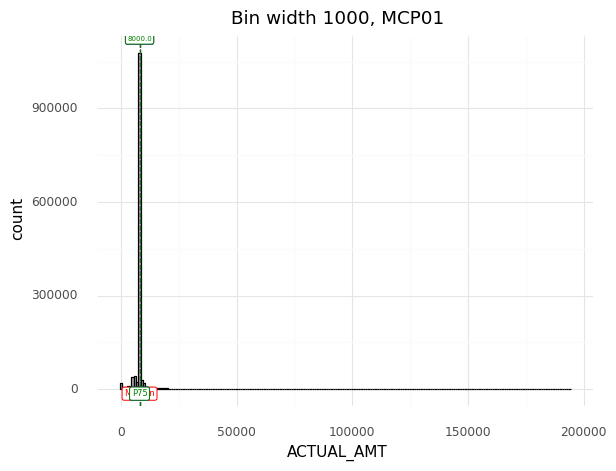

<ggplot: (129200791221)>

In [65]:
med_code = 'MCP01'
amt_field = 'ACTUAL_AMT'
upper_lim = 200000
lower_lim = 1
bin_width = 1000

dframe = pd.read_csv(os.path.join(directory + med_code + '.csv'), low_memory=False)

df2 = dframe[(dframe[amt_field] <= upper_lim) & \
          (~dframe[amt_field].isna()) & \
          (dframe[amt_field] >= lower_lim)][amt_field].to_frame()

med_value = df2[amt_field].median()
q_25 = df2[amt_field].quantile(0.25)
q_75 = df2[amt_field].quantile(0.75)
max_val = len(df2[amt_field])
graph_title = 'Bin width 1000, ' + med_code

p = ggplot(aes(x=amt_field), data=df2)
p + geom_histogram(binwidth=bin_width, 
#                    fill='blue',     # fill color
#                    breaks=list(np.arange(0, 100000, 2000)),
                   colour='black', # outline color
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(graph_title) \
    + geom_vline(
        mapping = aes(xintercept = med_value),
        linetype = "dashed",
        color = "red",
        size = 0.5
        ) \
    + annotate('label',x=med_value, y=math.inf, size=5, color='red', va='top', label=med_value) \
    + annotate('label',x=med_value, y=0, size=6, color='red', va='top', label='Median') \
    + geom_vline(
        mapping = aes(xintercept = q_25),
        linetype = "dashed",
        color = "blue",
        size = 0.5
        ) \
    + annotate('label',x=q_25, y=math.inf, size=5, color='blue', va='top', label=q_25) \
    + annotate('label',x=q_25, y=0, size=6, color='blue', va='top', label='P25') \
    + geom_vline(
        mapping = aes(xintercept = q_75),
        linetype = "dashed",
        color = "green",
        size = 0.5
        ) \
    + annotate('label',x=q_75, y=math.inf, size=5, color='green', va='top', label=q_75) \
    + annotate('label',x=q_75, y=0, size=6, color='green', va='top', label='P75') \
    + theme_minimal()

# for i in range(length_list):
#     df_input = pd.read_csv(os.path.join(directory + files_med_proc[i] + '.csv'), low_memory=False)
#     plot_histo(df_input, 'ACTUAL_AMT', 100000.0, 1.0, 1000, 'Bin width 1000' + files_med_proc[i])    

### NSD01

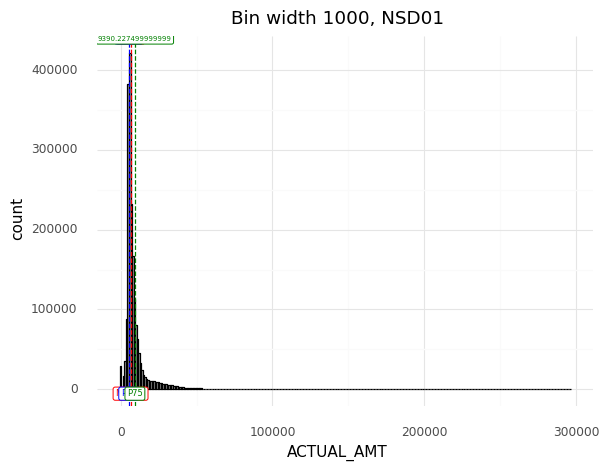

<ggplot: (129200475230)>

In [66]:
med_code = 'NSD01'
amt_field = 'ACTUAL_AMT'
upper_lim = 300000
lower_lim = 1
bin_width = 1000

dframe = pd.read_csv(os.path.join(directory + med_code + '.csv'), low_memory=False)

df2 = dframe[(dframe[amt_field] <= upper_lim) & \
          (~dframe[amt_field].isna()) & \
          (dframe[amt_field] >= lower_lim)][amt_field].to_frame()

med_value = df2[amt_field].median()
q_25 = df2[amt_field].quantile(0.25)
q_75 = df2[amt_field].quantile(0.75)
max_val = len(df2[amt_field])
graph_title = 'Bin width 1000, ' + med_code

p = ggplot(aes(x=amt_field), data=df2)
p + geom_histogram(binwidth=bin_width, 
#                    fill='blue',     # fill color
#                    breaks=list(np.arange(0, 100000, 2000)),
                   colour='black', # outline color
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(graph_title) \
    + geom_vline(
        mapping = aes(xintercept = med_value),
        linetype = "dashed",
        color = "red",
        size = 0.5
        ) \
    + annotate('label',x=med_value, y=math.inf, size=5, color='red', va='top', label=med_value) \
    + annotate('label',x=med_value, y=0, size=6, color='red', va='top', label='Median') \
    + geom_vline(
        mapping = aes(xintercept = q_25),
        linetype = "dashed",
        color = "blue",
        size = 0.5
        ) \
    + annotate('label',x=q_25, y=math.inf, size=5, color='blue', va='top', label=q_25) \
    + annotate('label',x=q_25, y=0, size=6, color='blue', va='top', label='P25') \
    + geom_vline(
        mapping = aes(xintercept = q_75),
        linetype = "dashed",
        color = "green",
        size = 0.5
        ) \
    + annotate('label',x=q_75, y=math.inf, size=5, color='green', va='top', label=q_75) \
    + annotate('label',x=q_75, y=0, size=6, color='green', va='top', label='P75') \
    + theme_minimal()

# for i in range(length_list):
#     df_input = pd.read_csv(os.path.join(directory + files_med_proc[i] + '.csv'), low_memory=False)
#     plot_histo(df_input, 'ACTUAL_AMT', 100000.0, 1.0, 1000, 'Bin width 1000' + files_med_proc[i])    

## XXXXX

### xxxxx

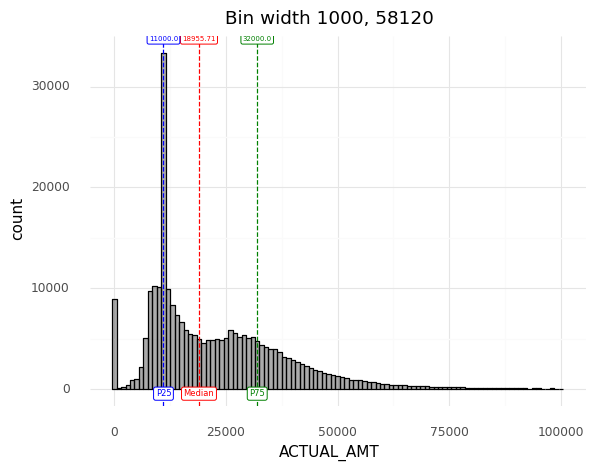

<ggplot: (129198864445)>

In [40]:
med_code = 'xxxxx'
amt_field = 'ACTUAL_AMT'
upper_lim = 100000
lower_lim = 1
bin_width = 1000

dframe = pd.read_csv(os.path.join(directory + med_code + '.csv'), low_memory=False)

df2 = dframe[(dframe[amt_field] <= upper_lim) & \
          (~dframe[amt_field].isna()) & \
          (dframe[amt_field] >= lower_lim)][amt_field].to_frame()

med_value = df2[amt_field].median()
q_25 = df2[amt_field].quantile(0.25)
q_75 = df2[amt_field].quantile(0.75)
max_val = len(df2[amt_field])
graph_title = 'Bin width 1000, ' + med_code

p = ggplot(aes(x=amt_field), data=df2)
p + geom_histogram(binwidth=bin_width, 
#                    fill='blue',     # fill color
#                    breaks=list(np.arange(0, 100000, 2000)),
                   colour='black', # outline color
                   size=0.5,        # thickness of outline
                   alpha=0.5        # transparency
                   ) \
    + ggtitle(graph_title) \
    + geom_vline(
        mapping = aes(xintercept = med_value),
        linetype = "dashed",
        color = "red",
        size = 0.5
        ) \
    + annotate('label',x=med_value, y=math.inf, size=5, color='red', va='top', label=med_value) \
    + annotate('label',x=med_value, y=0, size=6, color='red', va='top', label='Median') \
    + geom_vline(
        mapping = aes(xintercept = q_25),
        linetype = "dashed",
        color = "blue",
        size = 0.5
        ) \
    + annotate('label',x=q_25, y=math.inf, size=5, color='blue', va='top', label=q_25) \
    + annotate('label',x=q_25, y=0, size=6, color='blue', va='top', label='P25') \
    + geom_vline(
        mapping = aes(xintercept = q_75),
        linetype = "dashed",
        color = "green",
        size = 0.5
        ) \
    + annotate('label',x=q_75, y=math.inf, size=5, color='green', va='top', label=q_75) \
    + annotate('label',x=q_75, y=0, size=6, color='green', va='top', label='P75') \
    + theme_minimal()

# for i in range(length_list):
#     df_input = pd.read_csv(os.path.join(directory + files_med_proc[i] + '.csv'), low_memory=False)
#     plot_histo(df_input, 'ACTUAL_AMT', 100000.0, 1.0, 1000, 'Bin width 1000' + files_med_proc[i])    